In [1]:
import requests 

import pandas as pd

import sqlite3

#1. Connect to local SQLite database
conn = sqlite3.connect("fda_recalls.db")

#2. Fetch raw dataset from FDA API
fda_url = "https://api.fda.gov/drug/enforcement.json?limit=100"
response = requests.get(fda_url).json()

#3. Store raw results in DataFrame
fda_df = pd.DataFrame(response["results"])

#4. Create relational tables in SQLite
fda_df[['event_id', 'recalling_firm', 'classification', 'reason_for_recall']].to_sql('recall_details',conn,if_exists='replace', index=False)

fda_df[['event_id', 'city', 'state', 'distribution_pattern']].to_sql('recall_location',conn, if_exists='replace', index=False)

print("Database setup complete. Relational tables ready!")
                                                                     

Database setup complete. Relational tables ready!


In [2]:
join_query = """
SELECT DISTINCT 
    d.recalling_firm,
    l.city,
    l.state,
    d.classification,
    d.reason_for_recall,
    l.distribution_pattern
FROM recall_details d
JOIN recall_location l ON d.event_id = l.event_id
WHERE d.classification = 'Class I'
LIMIT 15;
"""

df_class1=pd.read_sql_query(join_query, conn)
df_class1.index = df_class1.index + 1 # Start row count at 1
df_class1

,recalling_firm,city,state,classification,reason_for_recall,distribution_pattern
1,Westminster Pharmaceuticals LLC,Olive Branch,MS,Class I,Failed Content Uniformity Specifications: Prod...,Nationwide in the USA and Puerto Rico
2,SG24 LLC,Bolingbroke,GA,Class I,Marketed without an Approved NDA/ANDA; product...,Nationwide
3,King Bio Inc.,Asheville,NC,Class I,Microbial contamination,"U.S.A. Nationwide, Canada, and Australia."
4,Aroma Release Technologies Inc,Chattanooga,TN,Class I,Marketed Without an Approved NDA/ANDA: Product...,Distributed in the states of Texas and New York.
5,www.vitaminbestbuy.com,Brewerton,NY,Class I,Marketed Without an Approved ANDA/NDA: presenc...,Nationwide
6,A&H Focal Inc.,Staten Island,NY,Class I,Marked Without An Approved NDA/ANDA: FDA analy...,"NY and NJ through six retail stores named ""Asi..."


In [3]:
clean_query = """
SELECT
    l.state,
    COUNT(*) AS recall_count
FROM recall_location l
WHERE l.state IS NOT NULL
    AND l.state != ''
    AND l.state != 'N/A'
GROUP BY l.state
ORDER BY recall_count DESC;
"""

df_clean = pd.read_sql_query(clean_query, conn)
df_clean.index = df_clean.index + 1 # Start row count at 1
df_clean.head(10)

,state,recall_count
1,NJ,11
2,NY,9
3,FL,9
4,IL,7
5,TX,6
6,OH,6
7,TN,5
8,CA,5
9,PA,4
10,NC,4


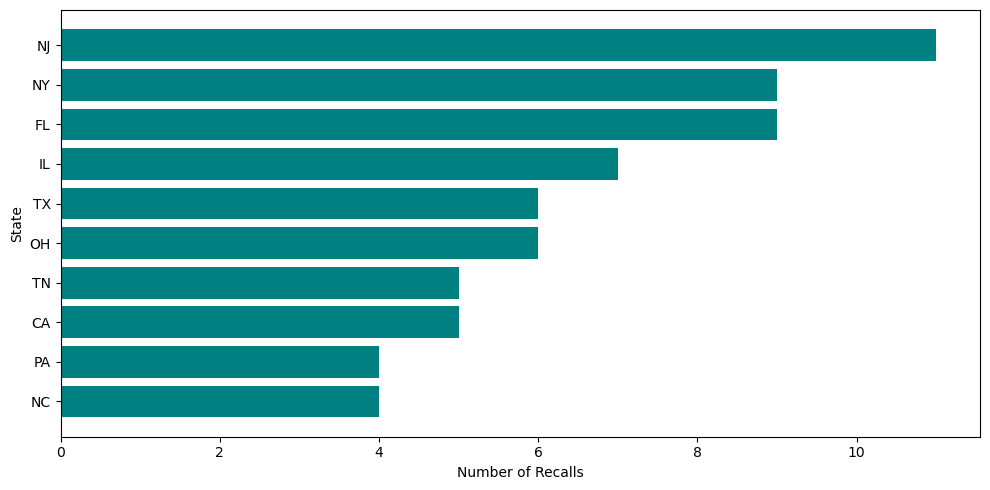

In [4]:
import matplotlib.pyplot as plt

top_10 = df_clean.head(10)

plt.figure(figsize=(10,5))
plt.barh(top_10['state'], top_10['recall_count'], color='teal')
plt.xlabel('Number of Recalls')
plt.ylabel('State')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
    

In [5]:
reason_query = """
SELECT
    CASE
        WHEN reason_for_recall LIKE '%microbiological%' OR reason_for_recall LIKE '%contamination%' THEN 'Contamination'
        WHEN reason_for_recall LIKE '%label%' OR reason_for_recall LIKE '%packaging%' THEN 'Labeling/Packaging'
        ELSE 'Other Quality Issue'
    END AS recall_category,
    COUNT(*) AS total_recalls
FROM recall_details
GROUP BY recall_category
ORDER BY total_recalls DESC;
"""

df_reasons = pd.read_sql_query(reason_query, conn)
df_reasons.index = df_reasons.index + 1 # Start row count at 1
df_reasons

,recall_category,total_recalls
1,Other Quality Issue,75
2,Labeling/Packaging,17
3,Contamination,8


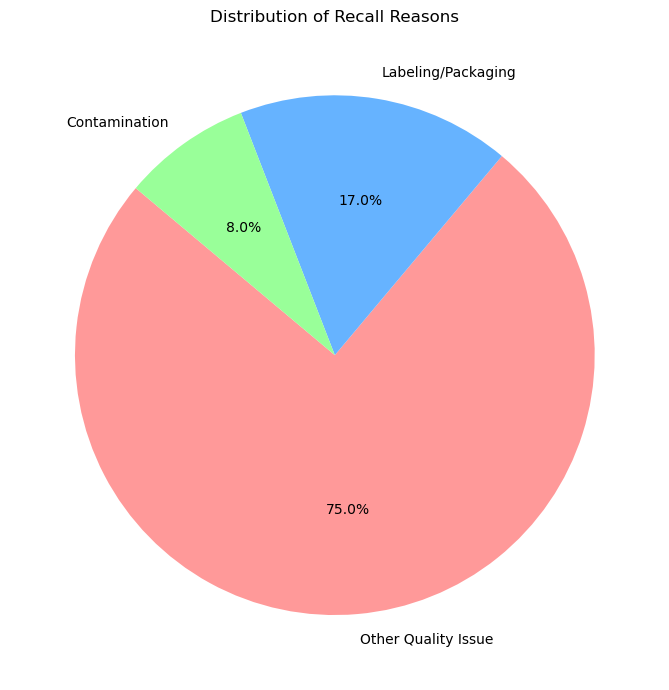

In [6]:
plt.figure(figsize=(7,7))
plt.pie(
    df_reasons['total_recalls'],
    labels=df_reasons['recall_category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Distribution of Recall Reasons')
plt.tight_layout()
plt.show()